In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.preprocessing import StandardScaler

In [2]:
# 1. LOAD DATASET (Menggunakan file yang sudah kita seleksi sebelumnya)
file_path = '#2 final feature selected dataset 6 for nphr.xlsx'
df_raw_1 = pd.read_excel(file_path)

In [3]:
df_raw_1

,Main steam temperature (boiler side) (℃),Flue gas temperature (℃),Boiler oxygen level (%),Main steam temperature (turbine side) (℃),Reheat steam temperature (turbine side) (℃),SO2 (mg/nm3),CO (mg/nm3),Velocity (m/s),Temp. (°C),NPHR (Kcal/Kwh),Pressure HRH,Temperature HRH
0,568.098974,130.708067,3.828501,564.647756,566.719831,467.109710,675.494230,13.543683,103.555908,2607.270106,2.29,566.36
1,568.023808,129.803971,3.659717,564.466986,563.985723,487.997713,677.919792,12.093034,99.353094,2687.121676,2.10,565.00
2,568.650337,127.860081,3.561764,565.077340,565.670929,498.073246,679.644721,11.900385,95.308560,2663.032090,2.09,565.63
3,568.262788,129.812856,3.905170,564.828538,564.237198,503.058633,682.033313,11.613680,87.355418,2651.943177,2.03,564.09
4,568.102547,130.218360,3.879849,564.945778,565.474856,450.895453,478.544209,12.103985,89.364968,2651.524408,2.13,565.75
...,...,...,...,...,...,...,...,...,...,...,...,...
544,567.188810,124.009406,3.292357,563.225716,564.490362,488.715044,791.996076,12.955925,108.685235,2362.587163,2.22,565.60
545,567.664945,123.268547,3.498842,563.826204,565.543734,485.453714,792.244088,12.270126,106.464384,2421.984297,2.08,565.79
546,567.590635,124.640201,3.468605,563.660633,566.011767,492.223928,792.396151,12.097462,102.674362,2522.739965,2.05,565.84
547,567.520828,127.187321,3.320881,563.597101,566.072634,500.705083,791.685285,12.569459,108.668248,2584.543200,2.12,566.30


In [4]:
# Pisahkan fitur dari target (Analisis VIF hanya dilakukan pada fitur input)
target_cols = ['NPHR (Kcal/Kwh)']
X_raw = df_raw_1.drop(columns=target_cols)

In [5]:
X_raw

,Main steam temperature (boiler side) (℃),Flue gas temperature (℃),Boiler oxygen level (%),Main steam temperature (turbine side) (℃),Reheat steam temperature (turbine side) (℃),SO2 (mg/nm3),CO (mg/nm3),Velocity (m/s),Temp. (°C),Pressure HRH,Temperature HRH
0,568.098974,130.708067,3.828501,564.647756,566.719831,467.109710,675.494230,13.543683,103.555908,2.29,566.36
1,568.023808,129.803971,3.659717,564.466986,563.985723,487.997713,677.919792,12.093034,99.353094,2.10,565.00
2,568.650337,127.860081,3.561764,565.077340,565.670929,498.073246,679.644721,11.900385,95.308560,2.09,565.63
3,568.262788,129.812856,3.905170,564.828538,564.237198,503.058633,682.033313,11.613680,87.355418,2.03,564.09
4,568.102547,130.218360,3.879849,564.945778,565.474856,450.895453,478.544209,12.103985,89.364968,2.13,565.75
...,...,...,...,...,...,...,...,...,...,...,...
544,567.188810,124.009406,3.292357,563.225716,564.490362,488.715044,791.996076,12.955925,108.685235,2.22,565.60
545,567.664945,123.268547,3.498842,563.826204,565.543734,485.453714,792.244088,12.270126,106.464384,2.08,565.79
546,567.590635,124.640201,3.468605,563.660633,566.011767,492.223928,792.396151,12.097462,102.674362,2.05,565.84
547,567.520828,127.187321,3.320881,563.597101,566.072634,500.705083,791.685285,12.569459,108.668248,2.12,566.30


In [6]:
# # 2. Preprocessing Dasar
# # Menghilangkan kolom dengan variansi nol (konstanta) yang bisa merusak VIF
# X_raw = X_raw.loc[:, X_raw.var() > 0]
# X_raw = X_raw.fillna(X_raw.median())

In [7]:
# 2. Normalisasi (Z-Score Scaling)
# Ini wajib karena VIF didasarkan pada regresi; perbedaan skala (misal Pressure vs Flow) 
# akan mengacaukan perhitungan jika tidak dinormalisasi.
scaler = StandardScaler()
X_scaled_values = scaler.fit_transform(X_raw)
X_scaled = pd.DataFrame(X_scaled_values, columns=X_raw.columns)

In [8]:
# 3. Perhitungan VIF untuk SEMUA fitur
def calculate_all_vif(data_frame):
    vif_data = pd.DataFrame()
    vif_data["Feature"] = data_frame.columns
    
    vif_list = []
    for i in range(len(data_frame.columns)):
        try:
            vif = variance_inflation_factor(data_frame.values, i)
            vif_list.append(vif)
        except Exception as e:
            # Jika ada varians nol, VIF akan menghasilkan nilai tak terhingga (inf)
            vif_list.append(np.inf)
            
    vif_data["VIF"] = vif_list
    return vif_data.sort_values(by="VIF", ascending=False)

In [9]:
# 1. Atur Pandas agar menampilkan 2 angka di belakang koma (tanpa eksponen)
pd.set_option('display.float_format', lambda x: '{:.2f}'.format(x))

In [10]:
# Eksekusi perhitungan
vif_results = calculate_all_vif(X_scaled)

In [11]:
vif_results

,Feature,VIF
3,Main steam temperature (turbine side) (℃),9.03
0,Main steam temperature (boiler side) (℃),8.49
4,Reheat steam temperature (turbine side) (℃),3.52
5,SO2 (mg/nm3),3.45
7,Velocity (m/s),3.44
9,Pressure HRH,3.24
10,Temperature HRH,2.98
2,Boiler oxygen level (%),2.28
8,Temp. (°C),2.21
1,Flue gas temperature (℃),1.89


Nilai VIF <10 untuk semua fitur terpilih menggunakan feature engineering MrMiMaxG-CVM

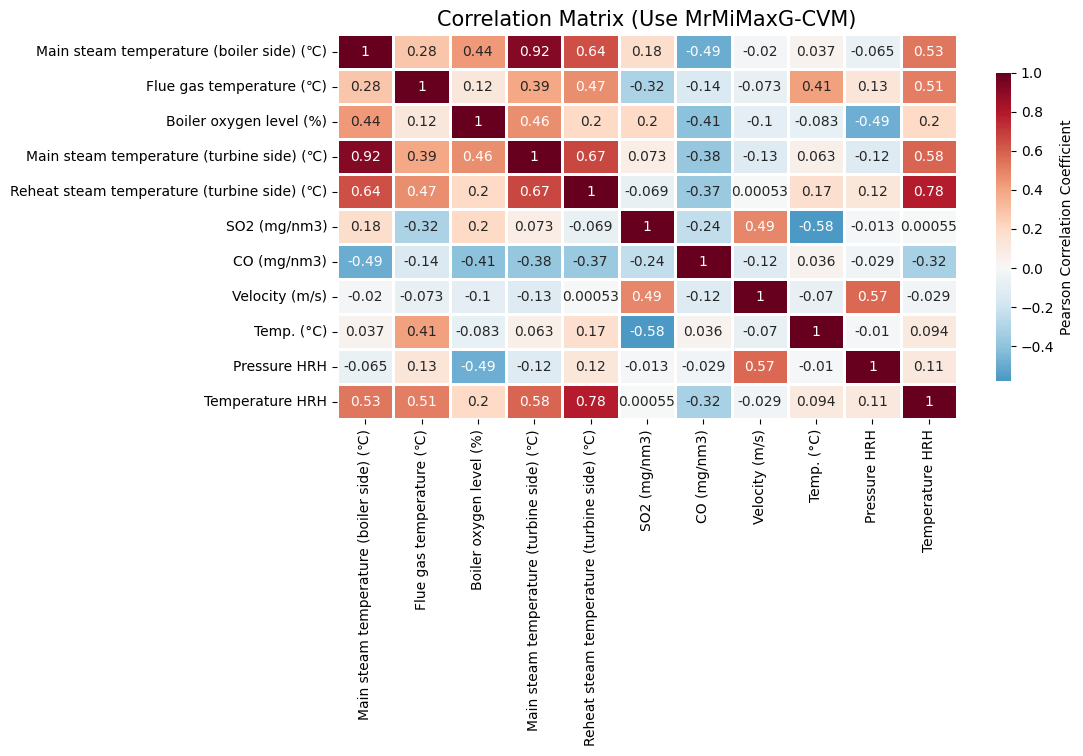

In [12]:
# A. Heatmap Korelasi (Matriks Kompleks)
plt.figure(figsize=(10, 5))
mask = np.tril(np.ones_like(X_scaled.corr(), dtype=bool))
sns.heatmap(X_scaled.corr(), 
            mask=None,          # Menampilkan format rectangle penuh
            annot=True,        # False karena 33 fitur terlalu padat untuk angka
            cmap='RdBu_r',      # Red-Blue (Merah = Positif, Biru = Negatif)
            center=0,           # Putih adalah korelasi 0
            linewidths=1,     # Memberikan garis tipis antar kotak (rectangle)
            linecolor='white',
            square=False,       # Memaksa format mengikuti aspek rasio figsize
            cbar_kws={"shrink": .8, "label": "Pearson Correlation Coefficient"})
plt.title('Correlation Matrix (Use MrMiMaxG-CVM)', fontsize=15)
plt.show()

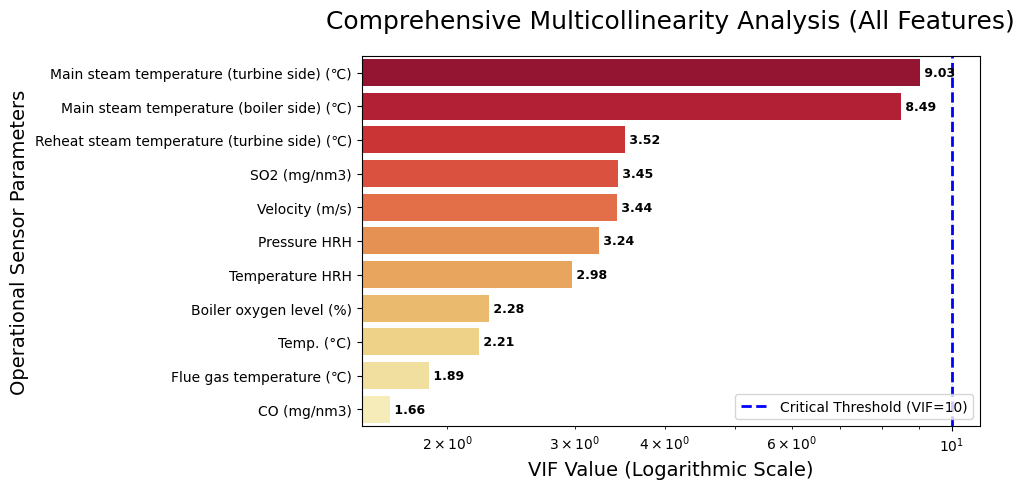

In [13]:
# 2. Mengatasi nilai 'inf' agar bisa tampil di grafik
max_real_vif = vif_results[vif_results['VIF'] != np.inf]['VIF'].max()
vif_results['VIF_Display'] = vif_results['VIF'].replace(np.inf, max_real_vif * 1.5)

# 3. Setup Figure
plt.figure(figsize=(10, 5))

# 4. Plot Bar Chart (PERBAIKAN DI SINI)
# Assign y ke hue dan tambahkan legend=False untuk menghilangkan warning
ax = sns.barplot(
    x='VIF_Display', 
    y='Feature', 
    data=vif_results, 
    palette='YlOrRd_r', 
    hue='Feature',    # Tambahkan ini
    legend=False      # Tambahkan ini
)

# 5. MENGGUNAKAN SKALA LOGARITMIK
plt.xscale('log')

# 6. Menambahkan Garis Threshold VIF=10
plt.axvline(x=10, color='blue', linestyle='--', linewidth=2, label='Critical Threshold (VIF=10)')

# 7. Menambahkan Label Angka di ujung bar
# Menggunakan zip untuk memastikan sinkronisasi data dengan bar
for i, (p, feature_name) in enumerate(zip(ax.patches, vif_results['Feature'])):
    width = p.get_width()
    # Mengambil nilai asli dari dataframe berdasarkan urutan index saat ini
    original_vif = vif_results.iloc[i]['VIF']
    label_text = 'inf' if original_vif == np.inf else f"{original_vif:.2f}"
    
    ax.text(width, p.get_y() + p.get_height()/2, f' {label_text}', 
            va='center', fontsize=9, fontweight='bold')

# 8. Judul dan Label
plt.title('Comprehensive Multicollinearity Analysis (All Features)', fontsize=18, pad=20)
plt.xlabel('VIF Value (Logarithmic Scale)', fontsize=14)
plt.ylabel('Operational Sensor Parameters', fontsize=14)
plt.legend(loc='lower right')
plt.grid(axis='x', linestyle=':', alpha=0.5)
plt.tight_layout()
plt.show()

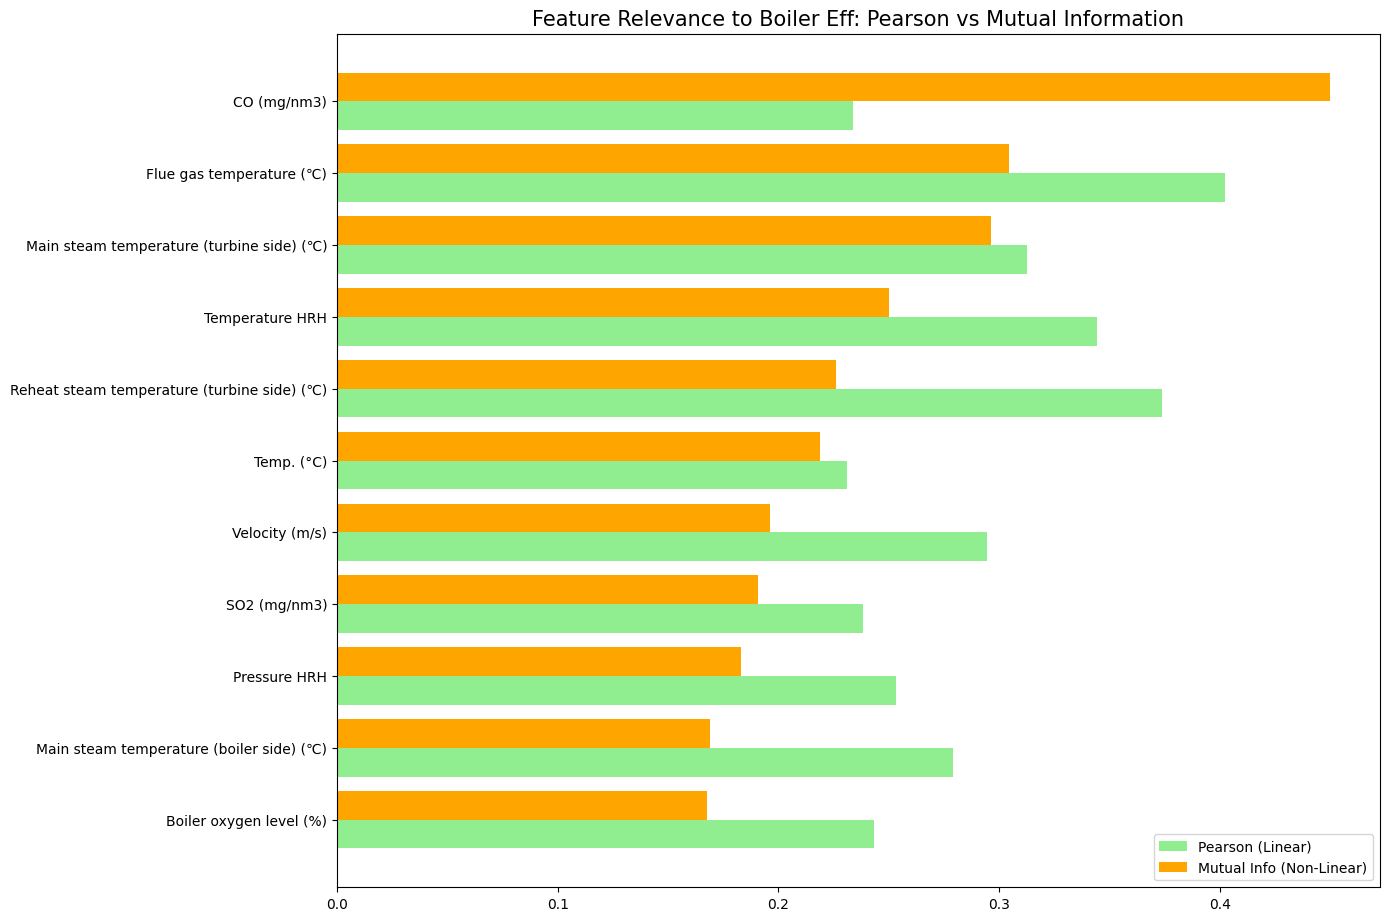

In [14]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.feature_selection import mutual_info_regression

# 1. Load Data
# df_raw_1 sudah didefinisikan sebelumnya
target_cols = ['NPHR (Kcal/Kwh)']
X = df_raw_1.drop(columns=target_cols)
y_eff = df_raw_1['NPHR (Kcal/Kwh)']

# 2. Hitung Korelasi Pearson (Linear) terhadap Target
pearson_eff = X.corrwith(y_eff).abs()

# 3. Hitung Mutual Information (Non-Linear) terhadap Target
# Kita perlu mengisi NaN jika ada agar MI bisa berjalan
X_fill = X.fillna(X.median())
mi_eff = mutual_info_regression(X_fill, y_eff, random_state=42)

# 4. Gabungkan dalam DataFrame untuk Visualisasi
importance_df = pd.DataFrame({
    'Feature': X.columns,
    'Pearson_Eff': pearson_eff.values,
    'MI_Eff': mi_eff
}).sort_values(by='MI_Eff', ascending=False)

# 5. Visualisasi Perbandingan Pearson vs MI (Justifikasi MrMiMaxG)
plt.figure(figsize=(14, 18))

# Subplot 2: Terhadap Boiler Efficiency
plt.subplot(2, 1, 2)
df_plot_eff = importance_df.sort_values('MI_Eff', ascending=True)
y_pos = np.arange(len(df_plot_eff))
plt.barh(y_pos - 0.2, df_plot_eff['Pearson_Eff'], 0.4, label='Pearson (Linear)', color='lightgreen')
plt.barh(y_pos + 0.2, df_plot_eff['MI_Eff'], 0.4, label='Mutual Info (Non-Linear)', color='orange')
plt.yticks(y_pos, df_plot_eff['Feature'])
plt.title('Feature Relevance to Boiler Eff: Pearson vs Mutual Information', fontsize=15)
plt.legend()

plt.tight_layout()
plt.show()